In [99]:
# Data Manipulation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import the pipeline function from Hugging Face Transformers
from transformers import pipeline

# Import PyTorch for working with the FinBERT model
import torch
import sys
!{sys.executable} -m pip install scikit-learn

In [98]:
import sys
!{sys.executable} -m pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.3 MB 836.8 kB/s eta 0:00:11
   --- ------------------------------------ 0.8/9.3 MB 874.5 kB/s eta 0:00:10
   ---- ----------------------------------- 1.0/9.3 MB 884.1 kB/s eta 0:00:10
   ---- ----------------------------------- 1.0/9.3 MB 884.1 kB/s eta 0:00:10
   ----- ---------------------------------- 1.3/9.3 MB 905.3 kB/s eta 0:00:09
   ------ --------------------------------- 1.6/9.3 MB 910.9 kB/s eta 0:00:09
   ------- -------------------------------- 1.8/9.3 MB 924.1 kB/s eta 0:00:09
   -------- ------------------------------- 2.1/

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
train= pd.read_parquet("data/train-00000-of-00001.parquet")
validation= pd.read_parquet("data/validation-00000-of-00001.parquet")
test= pd.read_parquet("data/test-00000-of-00001.parquet")
train.head()

,timestamp,ticker,tweet_url,label_1d_3class,author,category,session,market_regime,sector,market_cap_bucket,...,relative_volume,rsi_14,distance_from_ma_20,return_5d,return_20d,above_ma_20,slope_ma_20,gap_open,intraday_range,text
0,2025-01-02 04:01:12-05:00,GME,https://twitter.com/wallstengine/status/187474...,2,wallstengine,Other,premarket,calm,Consumer,mid_cap,...,0.568411,58.276897,0.059894,0.014239,0.149248,1.0,0.021540,0.001562,0.041862,"On New Year’s Day, Keith Gill, known as Roarin..."
1,2025-01-02 04:01:12-05:00,U,https://twitter.com/wallstengine/status/187474...,0,wallstengine,Other,premarket,calm,Technology,large_cap,...,0.561401,44.896435,-0.084930,0.004919,-0.073402,0.0,-0.008920,0.009773,0.030653,"On New Year’s Day, Keith Gill, known as Roarin..."
2,2025-01-02 04:01:48-05:00,RTX,https://twitter.com/wallstengine/status/187474...,1,wallstengine,Other,premarket,calm,Industrials,mega_cap,...,0.601497,42.555714,-0.010450,-0.007802,-0.024941,0.0,-0.007886,0.003038,0.010415,CHINA ADDS 28 US FIRMS TO EXPORT CONTROL LIST ...
3,2025-01-02 04:01:48-05:00,GD,https://twitter.com/wallstengine/status/187474...,2,wallstengine,Other,premarket,calm,Industrials,large_cap,...,0.510319,34.192986,-0.013510,-0.006410,-0.046846,0.0,-0.014835,0.002354,0.012795,CHINA ADDS 28 US FIRMS TO EXPORT CONTROL LIST ...
4,2025-01-02 04:09:02-05:00,NVDA,https://twitter.com/wallstengine/status/187474...,0,wallstengine,Mergers & Acquisitions,premarket,calm,Technology,mega_cap,...,0.859816,45.173355,-0.020842,-0.038519,-0.031306,0.0,0.001380,0.003491,0.030839,"BofA on $NVDA (Buy; $190 PT): ""Reiterate Buy o..."


In [3]:
import sys

print(sys.executable)

C:\Users\chane\AppData\Local\Programs\Python\Python313\python.exe


In [4]:
#list of train columns
train.columns.tolist()

['timestamp',
 'ticker',
 'tweet_url',
 'label_1d_3class',
 'author',
 'category',
 'session',
 'market_regime',
 'sector',
 'market_cap_bucket',
 'volatility_7d',
 'relative_volume',
 'rsi_14',
 'distance_from_ma_20',
 'return_5d',
 'return_20d',
 'above_ma_20',
 'slope_ma_20',
 'gap_open',
 'intraday_range',
 'text']

In [5]:
#check timestamp datatype
train["timestamp"].dtype

<StringDtype(na_value=nan)>

In [6]:
#Inspect Categorical columns

In [7]:
#inspecting label_1d_3class
train["label_1d_3class"].value_counts()

label_1d_3class
0    11806
2    11718
1     6903
Name: count, dtype: int64

In [8]:
train["label_1d_3class"].value_counts(normalize=True)

label_1d_3class
0    0.388011
2    0.385118
1    0.226871
Name: proportion, dtype: float64

In [9]:
train["ticker"].nunique()

1723

In [10]:
train["ticker"].value_counts().head(10)

ticker
NVDA     1614
TSLA     1067
GOOGL     867
AAPL      858
AMZN      840
META      832
QQQ       691
SPY       622
MSFT      612
HOOD      509
Name: count, dtype: int64

In [11]:
train["sector"].value_counts()

sector
Technology        10703
Consumer           6647
Communications     3617
Financials         2656
Industrials        2152
Other              1776
Healthcare         1754
Materials           340
Energy              317
Utilities           294
Real Estate         171
Name: count, dtype: int64

In [12]:
train["market_regime"].value_counts()

market_regime
calm             16012
volatile          8939
trending_up       3966
trending_down     1510
Name: count, dtype: int64

In [13]:
train["session"].value_counts()

session
regular       12739
premarket     10490
afterhours     7198
Name: count, dtype: int64

In [14]:
# different datatype in train
train.dtypes

timestamp                  str
ticker                     str
tweet_url                  str
label_1d_3class          int64
author                     str
category                   str
session                    str
market_regime              str
sector                     str
market_cap_bucket          str
volatility_7d          float32
relative_volume        float32
rsi_14                 float32
distance_from_ma_20    float32
return_5d              float32
return_20d             float32
above_ma_20            float32
slope_ma_20            float32
gap_open               float32
intraday_range         float32
text                       str
dtype: object

In [15]:
#inspect missing values
train.isnull().sum()

timestamp              0
ticker                 0
tweet_url              0
label_1d_3class        0
author                 0
category               0
session                0
market_regime          0
sector                 0
market_cap_bucket      0
volatility_7d          0
relative_volume        0
rsi_14                 0
distance_from_ma_20    0
return_5d              0
return_20d             0
above_ma_20            0
slope_ma_20            0
gap_open               0
intraday_range         0
text                   0
dtype: int64

In [16]:
# check duplicate values
train.duplicated().sum()

np.int64(0)

In [17]:
train.describe()

,label_1d_3class,volatility_7d,relative_volume,rsi_14,distance_from_ma_20,return_5d,return_20d,above_ma_20,slope_ma_20,gap_open,intraday_range
count,30427.000000,30427.000000,30427.000000,30427.000000,30427.000000,30427.000000,30427.000000,30427.000000,30427.000000,30427.000000,30427.000000
mean,0.997108,0.033960,1.265250,53.525723,0.019412,0.017989,0.057819,0.585960,0.007936,0.002262,0.045354
std,0.879287,0.051478,4.903702,13.545482,0.133690,0.232247,0.347102,0.492564,0.054688,0.040801,0.069665
min,0.000000,0.000000,0.000000,9.400650,-0.737671,-0.699111,-0.765333,0.000000,-0.405259,-0.396266,0.000000
25%,0.000000,0.015160,0.752935,43.687805,-0.035325,-0.031995,-0.065777,0.000000,-0.017015,-0.006711,0.020225
50%,1.000000,0.024132,0.977244,53.355118,0.015569,0.009308,0.025336,1.000000,0.005483,0.001343,0.032314
75%,2.000000,0.039674,1.361353,63.831257,0.059233,0.050417,0.117318,1.000000,0.025802,0.009240,0.053069
max,2.000000,2.635921,732.800049,100.000000,6.501042,29.542986,13.787799,1.000000,2.387972,2.521127,6.430338


In [18]:
#largest value in relative volume
train.nlargest(10, "relative_volume")[["timestamp","ticker","relative_volume","text","label_1d_3class"]]

,timestamp,ticker,relative_volume,text,label_1d_3class
23612,2025-07-01 08:30:04-04:00,BMNR,732.800049,🚨 Pre-market buzz! $WOLF $BMNR $BBAI $QBTS $HO...,0
24026,2025-07-09 08:34:28-04:00,PROK,258.484589,🚨 Pre-market buzz! $PROK $KIDZ $VRNA $AES $BMN...,0
5914,2025-02-18 09:14:57-05:00,WRD,228.880981,🚨 Pre-market buzz! $WRD +30% $STZ +7% $INTC +6...,1
23190,2025-06-25 15:16:18-04:00,SRFM,105.119751,$SRFM | Surf Air Mobility Announces $27M Regis...,0
583,2025-01-07 16:15:00-05:00,ARBE,99.341072,$ARBE ANNOUNCES $29M PUBLIC OFFERING Arbe Robo...,0
10382,2025-03-18 08:34:14-04:00,HYPR,90.267403,🚨 Pre-market buzz! $ADTX $SCNX $TIGR $NBTX $BT...,2
19535,2025-05-28 09:37:14-04:00,SGN,68.986221,SIGNING DAY SPORTS $SGN is merging with profit...,0
4644,2025-02-11 08:40:43-05:00,DOMH,53.366901,$DOMH is bringing on DONALD TRUMP JR. & ERIC T...,0
475,2025-01-07 05:42:03-05:00,FUBO,45.758026,$DIS | Redburn-Atlantic upgrades Disney (DIS) ...,2
484,2025-01-07 06:12:54-05:00,FUBO,45.758026,$FUBO | Wedbush Raises Target Price to $6.40 F...,2


In [19]:
#largest value in return_5d
train.nlargest(10, "return_5d")[
    ["timestamp","ticker","return_5d","text","label_1d_3class"]
]

,timestamp,ticker,return_5d,text,label_1d_3class
23775,2025-07-07 08:43:11-04:00,BMNR,29.542986,🚨 Pre-market buzz! $KALV $WOLF $WNS $GEO $CXW ...,0
23710,2025-07-03 10:53:53-04:00,BMNR,12.386727,$BMNR | BitMine Immersion is up +2300% in a we...,2
23612,2025-07-01 08:30:04-04:00,BMNR,6.704545,🚨 Pre-market buzz! $WOLF $BMNR $BBAI $QBTS $HO...,0
24026,2025-07-09 08:34:28-04:00,PROK,5.299612,🚨 Pre-market buzz! $PROK $KIDZ $VRNA $AES $BMN...,0
24670,2025-07-15 07:38:59-04:00,PROK,5.084089,📢 𝐉𝐔𝐒𝐓 𝐈𝐍: $PROK ProKidney Receives FDA Green ...,0
24720,2025-07-15 08:44:35-04:00,PROK,5.084089,🚨 Pre-market buzz! $XAGE $PROK $MP $BMNR $CRWV...,0
22589,2025-06-18 08:42:45-04:00,RGC,3.820766,🚨 Pre-market buzz! $MRVL $SMR $KFY $AFRM $NUE ...,0
882,2025-01-10 08:58:58-05:00,FUBO,3.246032,"$FUBO | ESPN, FOX, AND WARNER BROS. DISCOVERY ...",2
897,2025-01-10 11:35:01-05:00,FUBO,3.246032,"$DIS | Disney, Fox, and Warner Bros. Scrap Pla...",2
26732,2025-07-28 08:24:11-04:00,LIDR,2.924779,🚨 Pre-market buzz! $CELC $CRVO $LIDR $BTCS $WR...,0


In [20]:
#largest value in return_20d
train.nlargest(10, "return_20d")[["timestamp","ticker","return_20d","text","label_1d_3class"]]

,timestamp,ticker,return_20d,text,label_1d_3class
24025,2025-07-09 08:34:28-04:00,BMNR,13.787799,🚨 Pre-market buzz! $PROK $KIDZ $VRNA $AES $BMN...,2
1514,2025-01-17 04:24:37-05:00,NUKK,13.769784,Nukkleus $NUKK announced it has regained Nasda...,0
26528,2025-07-25 08:30:25-04:00,BMNR,8.553776,Eric Trump agreed with $ETH should be trading ...,2
25298,2025-07-17 17:02:50-04:00,BMNR,8.431579,$SBET ISSUES AN OFFERING TO BUY $6B OF ETHEREU...,0
25310,2025-07-17 17:21:08-04:00,BMNR,8.431579,$BMNR | Lee Thomas Jong has reported a planned...,0
26041,2025-07-23 08:18:34-04:00,BMNR,8.165909,$BMNR | Bitmine Immersion (Bmnr) Announces Com...,2
25597,2025-07-21 08:41:13-04:00,BMNR,8.010638,🚨 Pre-market buzz! $OPEN $DYNX $SBET $XYZ $S $...,2
26884,2025-07-28 17:34:07-04:00,BMNR,8.004525,$BMNR just put out this filing Who wants to ex...,0
26885,2025-07-28 17:36:53-04:00,BMNR,8.004525,$BMNR | BitMine Immersion is down more than 18...,0
26334,2025-07-24 11:24:58-04:00,BMNR,7.936652,Tom Lee's new $BMNR Ethereum Treasury company ...,2


In [21]:
# 10 smallest values in return_5d
train.nsmallest(10,"return_5d")[
    ["timestamp","ticker","return_5d","text","label_1d_3class"]
]

,timestamp,ticker,return_5d,text,label_1d_3class
24541,2025-07-14 08:53:35-04:00,BMNR,-0.699111,Tom Lee's new $BMNR Ethereum Treasury company ...,2
24543,2025-07-14 08:59:00-04:00,BMNR,-0.699111,BREAKING: Bitmine doubles their Ethereum holdi...,2
24545,2025-07-14 09:27:12-04:00,BMNR,-0.699111,📢 𝐉𝐔𝐒𝐓 𝐈𝐍: $BMNR Bitmine Immersion Now Holds A...,2
24651,2025-07-14 17:17:51-04:00,BMNR,-0.699111,$BMNR | Director Lee Thomas Jong buys Bitmine ...,0
10372,2025-03-18 08:34:14-04:00,ADTX,-0.687857,🚨 Pre-market buzz! $ADTX $SCNX $TIGR $NBTX $BT...,0
1142,2025-01-14 12:16:23-05:00,RGTI,-0.681914,📢 𝐉𝐔𝐒𝐓 𝐈𝐍: Microsoft Launches Quantum Ready Pr...,0
1157,2025-01-14 15:14:40-05:00,RGTI,-0.681914,📢 𝐉𝐔𝐒𝐓 𝐈𝐍: SEEQC Secures $30M to Revolutionize...,0
1166,2025-01-14 15:17:09-05:00,RGTI,-0.681914,Could this be considered hypocrisy on Nvidia's...,0
1187,2025-01-14 15:37:26-05:00,RGTI,-0.681914,📢 𝐉𝐔𝐒𝐓 𝐈𝐍: $IONQ Maryland Launches $1 Billion ...,0
24985,2025-07-16 08:31:15-04:00,BMNR,-0.641614,🚨 Pre-market buzz! $NUWE $BMNR $RPTX $DPRO $BH...,0


In [22]:
print("Train", train.shape)
print("Validation", validation.shape)
print("Test", test.shape)

Train (30427, 21)
Validation (6520, 21)
Test (6521, 21)


In [23]:
#check the earliest and latest timestamp in each dataset
print("Train:", train["timestamp"].min(), "→", train["timestamp"].max())
print("Validation:", validation["timestamp"].min(),"→",validation["timestamp"].max())
print("Test:", test["timestamp"].min(), "→", test["timestamp"].max())

Train: 2025-01-02 04:01:12-05:00 → 2025-08-27 10:10:41-04:00
Validation: 2025-08-27 10:10:41-04:00 → 2025-11-04 17:00:26-05:00
Test: 2025-11-04 17:00:26-05:00 → 2025-12-31 19:21:08-05:00


In [24]:
#check if one tweet exist in every dataset
print("Train n Validation:", len(set(train["tweet_url"]) & set(validation["tweet_url"])))
print("Validation n Test:", len(set(validation["tweet_url"]) & set(test["tweet_url"])))
print("Train n Test:", len(set(train["tweet_url"]) & set(test["tweet_url"])))

Train n Validation: 1
Validation n Test: 1
Train n Test: 0


In [25]:
train_val_overlap = set(train["tweet_url"]) & set(validation["tweet_url"])

validation_test_overlap = set(validation["tweet_url"]) & set(test["tweet_url"])

print("Train/Validation overlapping tweet:")
print(train[train["tweet_url"].isin(train_val_overlap)][
    ["timestamp", "ticker", "tweet_url", "text", "label_1d_3class"]
])

print("\nValidation/Test overlapping tweet:")
print(validation[validation["tweet_url"].isin(validation_test_overlap)][
    ["timestamp", "ticker", "tweet_url", "text", "label_1d_3class"]
])

Train/Validation overlapping tweet:
                       timestamp ticker  \
30423  2025-08-27 10:10:41-04:00    LLY   
30424  2025-08-27 10:10:41-04:00   META   
30425  2025-08-27 10:10:41-04:00   UBER   
30426  2025-08-27 10:10:41-04:00   NVDA   

                                               tweet_url  \
30423  https://twitter.com/wallstengine/status/196070...   
30424  https://twitter.com/wallstengine/status/196070...   
30425  https://twitter.com/wallstengine/status/196070...   
30426  https://twitter.com/wallstengine/status/196070...   

                                                    text  label_1d_3class  
30423  According to @prospero_ai, here are their top ...                2  
30424  According to @prospero_ai, here are their top ...                2  
30425  According to @prospero_ai, here are their top ...                2  
30426  According to @prospero_ai, here are their top ...                1  

Validation/Test overlapping tweet:
                      timestamp

In [26]:
# inspect label_1d_3class relationship with other features
train.groupby("label_1d_3class")[[
    "return_5d",
    "return_20d",
    "volatility_7d",
    "relative_volume"
]].mean()

,return_5d,return_20d,volatility_7d,relative_volume
label_1d_3class,,,,
0,0.018552,0.065476,0.036742,1.353099
1,0.015071,0.043563,0.023305,1.115443
2,0.019140,0.058502,0.037433,1.264991


In [27]:
#understand category column
train["category"].value_counts()

category
Other                     11783
Earnings                   5812
Guidance & Forecasts       3670
Regulatory & Legal         1595
Personnel Changes          1549
Partnerships & Deals       1248
Market Data                1191
Product Launch             1172
Mergers & Acquisitions      974
Company Strategy            924
Breaking News               341
Company Metrics             168
Name: count, dtype: int64

In [28]:
train[["category","text","label_1d_3class"]].head(10)

,category,text,label_1d_3class
0,Other,"On New Year’s Day, Keith Gill, known as Roarin...",2
1,Other,"On New Year’s Day, Keith Gill, known as Roarin...",0
2,Other,CHINA ADDS 28 US FIRMS TO EXPORT CONTROL LIST ...,1
3,Other,CHINA ADDS 28 US FIRMS TO EXPORT CONTROL LIST ...,2
4,Mergers & Acquisitions,"BofA on $NVDA (Buy; $190 PT): ""Reiterate Buy o...",0
5,Guidance & Forecasts,"Keefe, Bruyette & Woods Downgrades $SOFI to Un...",2
6,Earnings,"UBS on $AAPL (Neutral, PT $236): 'Lowers iPhon...",2
7,Guidance & Forecasts,"Goldman Sachs Upgrades $NET to Buy from Sell, ...",1
8,Partnerships & Deals,Alibaba Cloud $BABA and AI startup 01:AI have ...,0
9,Mergers & Acquisitions,Raymond James Upgrades $MMS to Outperform from...,2


In [29]:
#inspect the length of tweets
train["text"].str.len().describe()

count    30427.000000
mean       295.603411
std        395.939583
min         30.000000
25%        109.000000
50%        155.000000
75%        287.000000
max      10423.000000
Name: text, dtype: float64

In [30]:
#inspect sentiment-related words
sentiment_words = r"\b(buy|sell|hold|upgrade|downgrade|bullish|bearish|positive|negative)\b"

train["text"].str.lower().str.count(sentiment_words).sum()

np.int64(4619)

In [31]:
#how many individual tweets contain at least one of these words?
sentiment_words = r"\b(?:buy|sell|hold|upgrade|downgrade|bullish|bearish|positive|negative)\b"

has_sentiment_word = train["text"].str.lower().str.contains(
    sentiment_words,
    regex=True,
    na=False
)

has_sentiment_word.sum()

np.int64(2647)

In [32]:
train["tweet_url"].nunique()

14805

In [33]:
#Count each word
words = [
    "buy","sell","hold","upgrade","downgrade","bullish","bearish","positive","negative"
]

word_counts = {}
for word in words:
    word_counts[word] = train["text"].str.lower().str.contains(
        rf"\b{word}\b",
        regex=True,
        na=False
    ).sum()
word_counts

{'buy': np.int64(1512),
 'sell': np.int64(740),
 'hold': np.int64(279),
 'upgrade': np.int64(143),
 'downgrade': np.int64(114),
 'bullish': np.int64(220),
 'bearish': np.int64(28),
 'positive': np.int64(423),
 'negative': np.int64(182)}

In [34]:
#inspect label_id_3class because this column seems connected to the next day stoc direction
train["label_1d_3class"].value_counts()

label_1d_3class
0    11806
2    11718
1     6903
Name: count, dtype: int64

In [35]:
train.shape

(30427, 21)

In [36]:
train["tweet_url"].duplicated().sum()

np.int64(15622)

In [37]:
train["tweet_url"].nunique()

14805

In [38]:
#why the same tweet URL appears in multiple rows
train[train["tweet_url"].duplicated(keep=False)].head(10)

,timestamp,ticker,tweet_url,label_1d_3class,author,category,session,market_regime,sector,market_cap_bucket,...,relative_volume,rsi_14,distance_from_ma_20,return_5d,return_20d,above_ma_20,slope_ma_20,gap_open,intraday_range,text
0,2025-01-02 04:01:12-05:00,GME,https://twitter.com/wallstengine/status/187474...,2,wallstengine,Other,premarket,calm,Consumer,mid_cap,...,0.568411,58.276897,0.059894,0.014239,0.149248,1.0,0.021540,0.001562,0.041862,"On New Year’s Day, Keith Gill, known as Roarin..."
1,2025-01-02 04:01:12-05:00,U,https://twitter.com/wallstengine/status/187474...,0,wallstengine,Other,premarket,calm,Technology,large_cap,...,0.561401,44.896435,-0.084930,0.004919,-0.073402,0.0,-0.008920,0.009773,0.030653,"On New Year’s Day, Keith Gill, known as Roarin..."
2,2025-01-02 04:01:48-05:00,RTX,https://twitter.com/wallstengine/status/187474...,1,wallstengine,Other,premarket,calm,Industrials,mega_cap,...,0.601497,42.555714,-0.010450,-0.007802,-0.024941,0.0,-0.007886,0.003038,0.010415,CHINA ADDS 28 US FIRMS TO EXPORT CONTROL LIST ...
3,2025-01-02 04:01:48-05:00,GD,https://twitter.com/wallstengine/status/187474...,2,wallstengine,Other,premarket,calm,Industrials,large_cap,...,0.510319,34.192986,-0.013510,-0.006410,-0.046846,0.0,-0.014835,0.002354,0.012795,CHINA ADDS 28 US FIRMS TO EXPORT CONTROL LIST ...
14,2025-01-02 07:02:32-05:00,BDC,https://twitter.com/wallstengine/status/187478...,2,wallstengine,Other,premarket,calm,Technology,mid_cap,...,0.893361,37.457882,-0.047748,-0.007754,-0.091195,0.0,-0.020285,0.002051,0.019527,"Goldman Sachs has added Belden $BDC, Norwegian..."
15,2025-01-02 07:02:32-05:00,TPG,https://twitter.com/wallstengine/status/187478...,0,wallstengine,Other,premarket,calm,Financials,large_cap,...,0.532708,38.083138,-0.054177,-0.016434,-0.088350,0.0,-0.022913,0.006939,0.025706,"Goldman Sachs has added Belden $BDC, Norwegian..."
16,2025-01-02 07:02:32-05:00,FOXA,https://twitter.com/wallstengine/status/187478...,0,wallstengine,Other,premarket,calm,Communications,large_cap,...,0.301305,56.724258,0.012569,-0.017594,0.038700,1.0,0.014678,-0.000410,0.009828,"Goldman Sachs has added Belden $BDC, Norwegian..."
17,2025-01-02 07:02:32-05:00,NCLH,https://twitter.com/wallstengine/status/187478...,2,wallstengine,Other,premarket,calm,Consumer,mid_cap,...,0.497764,45.214676,-0.029697,-0.015308,-0.092416,0.0,-0.012108,-0.006990,0.022913,"Goldman Sachs has added Belden $BDC, Norwegian..."
18,2025-01-02 07:02:32-05:00,PH,https://twitter.com/wallstengine/status/187478...,2,wallstengine,Other,premarket,calm,Industrials,large_cap,...,0.331129,31.978312,-0.045664,-0.014900,-0.092280,0.0,-0.021587,0.000660,0.010301,"Goldman Sachs has added Belden $BDC, Norwegian..."
20,2025-01-02 07:22:45-05:00,RIOT,https://twitter.com/AIStockSavvy/status/187479...,2,AIStockSavvy,Market Data,premarket,calm,Financials,mid_cap,...,0.641362,41.256535,-0.142629,-0.054630,-0.156198,0.0,-0.022291,0.025714,0.083333,"📢 𝐉𝐔𝐒𝐓 𝐈𝐍: Bitcoin Set to Skyrocket to $225,00..."


In [39]:
#inspect some actual tweets(text)
train["text"].head(10).to_list()

["On New Year’s Day, Keith Gill, known as Roaring Kitty, shared a tweet featuring a GIF from Dave Chappelle's skit as Rick James. In the GIF, Rick James wears a ring with the word 'UNITY' on it.  cc: $U $GME",
 "On New Year’s Day, Keith Gill, known as Roaring Kitty, shared a tweet featuring a GIF from Dave Chappelle's skit as Rick James. In the GIF, Rick James wears a ring with the word 'UNITY' on it.  cc: $U $GME",
 "CHINA ADDS 28 US FIRMS TO EXPORT CONTROL LIST China's Commerce Ministry has placed companies including Boeing Defense $BA, Lockheed Martin $LMT, Raytheon Missiles &amp; Defense $RTX, and General Dynamics $GD on its export control list.",
 "CHINA ADDS 28 US FIRMS TO EXPORT CONTROL LIST China's Commerce Ministry has placed companies including Boeing Defense $BA, Lockheed Martin $LMT, Raytheon Missiles &amp; Defense $RTX, and General Dynamics $GD on its export control list.",
 'BofA on $NVDA (Buy; $190 PT): "Reiterate Buy on our sector top pick, Nvidia , ahead of CES tradesh

In [40]:
train.columns.tolist()

['timestamp',
 'ticker',
 'tweet_url',
 'label_1d_3class',
 'author',
 'category',
 'session',
 'market_regime',
 'sector',
 'market_cap_bucket',
 'volatility_7d',
 'relative_volume',
 'rsi_14',
 'distance_from_ma_20',
 'return_5d',
 'return_20d',
 'above_ma_20',
 'slope_ma_20',
 'gap_open',
 'intraday_range',
 'text']

In [41]:
!pip install transformers torch

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [42]:
import sys

print(sys.executable)

C:\Users\chane\AppData\Local\Programs\Python\Python313\python.exe


In [43]:
!{sys.executable} -m pip install transformers torch

In [45]:
import sys

# Show which Python Jupyter is using
print("Python:", sys.executable)

# Import Transformers
import transformers

# Import PyTorch
import torch

# Show installed versions
print("Transformers:", transformers.__version__)
print("PyTorch:", torch.__version__)

Python: C:\Users\chane\AppData\Local\Programs\Python\Python313\python.exe
Transformers: 5.16.1
PyTorch: 2.14.0+cpu


In [46]:
#test FinBERT on 5 tweets
from transformers import pipeline

# Create a financial sentiment analysis model
sentiment_pipeline = pipeline(
    "text-classification",
    model="ProsusAI/finbert"
)

# Select 5 tweets from our training data
sample_texts = train["text"].head(5).tolist()

# Analyze their sentiment
results = sentiment_pipeline(
    sample_texts,
    truncation=True,
    max_length=512
)

results

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 3969.95it/s]


[{'label': 'neutral', 'score': 0.9177331924438477},
 {'label': 'neutral', 'score': 0.9177331924438477},
 {'label': 'neutral', 'score': 0.8282269239425659},
 {'label': 'neutral', 'score': 0.8282269239425659},
 {'label': 'neutral', 'score': 0.6221948862075806}]

In [47]:
#find tweets containing upgrade, downgrade, bullish, bearish, buy, or sell
# Find rows containing financial sentiment words
sentiment_examples = train[
    train["text"].str.lower().str.contains(
        r"\b(?:upgrade|downgrade|bullish|bearish|buy|sell)\b",
        regex=True,
        na=False
    )
]

# Take 5 examples
sample_texts = sentiment_examples["text"].head(5).tolist()

# Show the tweets
for i, text in enumerate(sample_texts, 1):
    print(f"\n--- Tweet {i} ---")
    print(text)


--- Tweet 1 ---
BofA on $NVDA (Buy; $190 PT): "Reiterate Buy on our sector top pick, Nvidia , ahead of CES tradeshow that starts Jan-6 with keynote and other events featuring NVDA CEO." "While the big themes have already been mentioned in the media ahead of the event, we still see CES as a positive catalyst, re-asserting NVDA’s platform dominance/opportunity in high-growth markets. "Specifically, we look for updates on: 1) Robotics strategy (Jetson Thor) from silicon to software and emergence of 'physical AI' theme, 2) Launch of RTX 50xx, Blackwell variants of PC gaming cards with enhanced 'neural rendering' and faster GDDR7 memory, 3) Potential entry into AI PC likely via partnership or (small) chance of standalone PC CPU, and 4) Update on data center incl. current-gen Blackwell (GB200, B200), 2H upgraded variants (GB300, B300 – more memory (288GB using 12 stack High HBM 3E) for more accurate AI inference) and teaser on next-gen Rubin (CY26E)." Analyst: Vivek Arya

--- Tweet 2 ---
Ke

In [48]:
# Analyze the 5 financial tweets with FinBERT
results = sentiment_pipeline(
    sample_texts,
    truncation=True,
    max_length=512
)

# Display the results
for i, result in enumerate(results, 1):
    print(f"Tweet {i}: {result}")

Tweet 1: {'label': 'neutral', 'score': 0.6221948862075806}
Tweet 2: {'label': 'negative', 'score': 0.6738439798355103}
Tweet 3: {'label': 'negative', 'score': 0.9665637612342834}
Tweet 4: {'label': 'negative', 'score': 0.908556342124939}
Tweet 5: {'label': 'positive', 'score': 0.9398602247238159}


In [51]:
# Take the first 10 tweets from the training dataset
sample_texts = train["text"].head(10).tolist()

# use FinBERT to anlyse their sentiment
sample_results = sentiment_pipeline(
    sample_texts,
    truncation=True,
    max_length=512
)

#Display each tweet with its sentiment
for i, result in enumerate(sample_results, 1):
    print(f"Tweet {i}")
    print("Sentiment: ", result["label"])
    print("Score: ", result["score"])
    print()

Tweet 1
Sentiment:  neutral
Score:  0.9177331924438477

Tweet 2
Sentiment:  neutral
Score:  0.9177331924438477

Tweet 3
Sentiment:  neutral
Score:  0.8282269239425659

Tweet 4
Sentiment:  neutral
Score:  0.8282269239425659

Tweet 5
Sentiment:  neutral
Score:  0.6221948862075806

Tweet 6
Sentiment:  negative
Score:  0.6738439798355103

Tweet 7
Sentiment:  negative
Score:  0.9665637612342834

Tweet 8
Sentiment:  negative
Score:  0.908556342124939

Tweet 9
Sentiment:  positive
Score:  0.8848370313644409

Tweet 10
Sentiment:  negative
Score:  0.934873640537262



In [53]:
#Create a copy of the first 10 rows
test_sentiment = train.head(10).copy()

#Add FinBERT results
test_sentiment["sentiment"] = [result["label"] for result in sample_results]

test_sentiment["sentiment_score"] = [result["score"] for result in sample_results]

#Display the important columns
test_sentiment[
    ["ticker","text","sentiment","sentiment_score", "label_1d_3class"]
    ]

,ticker,text,sentiment,sentiment_score,label_1d_3class
0,GME,"On New Year’s Day, Keith Gill, known as Roarin...",neutral,0.917733,2
1,U,"On New Year’s Day, Keith Gill, known as Roarin...",neutral,0.917733,0
2,RTX,CHINA ADDS 28 US FIRMS TO EXPORT CONTROL LIST ...,neutral,0.828227,1
3,GD,CHINA ADDS 28 US FIRMS TO EXPORT CONTROL LIST ...,neutral,0.828227,2
4,NVDA,"BofA on $NVDA (Buy; $190 PT): ""Reiterate Buy o...",neutral,0.622195,0
5,SOFI,"Keefe, Bruyette & Woods Downgrades $SOFI to Un...",negative,0.673844,2
6,AAPL,"UBS on $AAPL (Neutral, PT $236): 'Lowers iPhon...",negative,0.966564,2
7,NET,"Goldman Sachs Upgrades $NET to Buy from Sell, ...",negative,0.908556,1
8,BABA,Alibaba Cloud $BABA and AI startup 01:AI have ...,positive,0.884837,0
9,MMS,Raymond James Upgrades $MMS to Outperform from...,negative,0.934874,2


In [56]:
# process the full training dataset ; apply FinBERT to the entire training dataset
#create a function
def get_sentiment_in_batches(texts, batch_size=16):
    sentiments = []
    scores = []

    # Process the texts batch by batch
    for i in range(0, len(texts), batch_size):

        # Get the current batch
        batch = texts[i:i + batch_size]

        # Analyze the batch with FinBERT
        results = sentiment_pipeline(
            batch,
            truncation=True,
            max_length=512
        )

        # Save sentiment and score
        sentiments.extend([result["label"] for result in results])
        scores.extend([result["score"] for result in results])

        # Show progress
        print(f"Processed {min(i + batch_size, len(texts))} / {len(texts)}")

    return sentiments, scores

In [57]:
# Convert the tweet column to a list
texts = train["text"].tolist()

# Process tweets in batches
sentiments, scores = get_sentiment_in_batches(
    texts,
    batch_size=16
)

Processed 16 / 30427
Processed 32 / 30427
Processed 48 / 30427
Processed 64 / 30427
Processed 80 / 30427
Processed 96 / 30427
Processed 112 / 30427
Processed 128 / 30427
Processed 144 / 30427
Processed 160 / 30427
Processed 176 / 30427
Processed 192 / 30427
Processed 208 / 30427
Processed 224 / 30427
Processed 240 / 30427
Processed 256 / 30427
Processed 272 / 30427
Processed 288 / 30427
Processed 304 / 30427
Processed 320 / 30427
Processed 336 / 30427
Processed 352 / 30427
Processed 368 / 30427
Processed 384 / 30427
Processed 400 / 30427
Processed 416 / 30427
Processed 432 / 30427
Processed 448 / 30427
Processed 464 / 30427
Processed 480 / 30427
Processed 496 / 30427
Processed 512 / 30427
Processed 528 / 30427
Processed 544 / 30427
Processed 560 / 30427
Processed 576 / 30427
Processed 592 / 30427
Processed 608 / 30427
Processed 624 / 30427
Processed 640 / 30427
Processed 656 / 30427
Processed 672 / 30427
Processed 688 / 30427
Processed 704 / 30427
Processed 720 / 30427
Processed 736 / 

In [58]:
train["sentiment"] = sentiments
train["sentiment_score"] = scores

In [59]:
train["sentiment"].value_counts()

sentiment
neutral     16724
positive     9678
negative     4025
Name: count, dtype: int64

In [60]:
pd.crosstab(
    train["sentiment"],
    train["label_1d_3class"]
)

label_1d_3class,0,1,2
sentiment,,,
negative,1500,856,1669
neutral,6344,4246,6134
positive,3962,1801,3915


In [61]:
pd.crosstab(
    train["sentiment"],
    train["label_1d_3class"],
    normalize="index"
) * 100

label_1d_3class,0,1,2
sentiment,,,
negative,37.267081,21.267081,41.465839
neutral,37.933509,25.388663,36.677828
positive,40.938210,18.609217,40.452573


In [65]:
from scipy.stats import chi2_contingency

# Create the contingency table
table = pd.crosstab(
    train["sentiment"],
    train["label_1d_3class"]
)

# Perform the Chi-square test
chi2, p_value, degrees_of_freedom, expected = chi2_contingency(table)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", degrees_of_freedom)

Chi-square statistic: 178.5851622320702
p-value: 1.5009865975671994e-37
Degrees of freedom: 4


In [63]:
import sys
!{sys.executable} -m pip install scipy

   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ---------------------------------------- 0.3/36.6 MB ? eta -:--:--
    --------------------------------------- 0.8/36.6 MB 2.5 MB/s eta 0:00:15
   -- ------------------------------------- 1.8/36.6 MB 3.9 MB/s eta 0:00:09
   ---- ----------------------------------- 3.7/36.6 MB 5.5 MB/s eta 0:00:06
   ---- ----------------------------------- 3.7/36.6 MB 5.5 MB/s eta 0:00:06
   -------- ------------------------------- 7.9/36.6 MB 7.1 MB/s eta 0:00:05
   ---------- ----------------------------- 9.2/36.6 MB 6.8 MB/s eta 0:00:05
   ----------- ---------------------------- 10.7/36.6 MB 7.3 MB/s eta 0:00:04
   ------------- -------------------------- 12.1/36.6 MB 6.8 MB/s eta 0:00:04
   ----------------- ---------------------- 16.0/36.6 MB 8.2 MB/s eta 0:00:03
   -------------------- ------------------- 18.6/36.6 MB 8.5 MB/s eta 0:00:03
   -------------

In [64]:
from scipy.stats import chi2_contingency

print("SciPy is working!")

SciPy is working!


In [66]:
#Cramer's V
import numpy as np

n = table.sum().sum()
cramers_v = np.sqrt(chi2 / (n * min(table.shape[0] - 1, table.shape[1] - 1)))

print("Cramér's V:", cramers_v)

Cramér's V: 0.05417240557350068


In [67]:
print(train.shape)

print(validation.shape)

print(test.shape)

(30427, 23)
(6520, 21)
(6521, 21)


In [68]:
#add validation sentiment
validation_sentiments, validation_scores = get_sentiment_in_batches(
    validation["text"].tolist(),
    batch_size=16
)

validation["sentiment"] = validation_sentiments
validation["sentiment_score"] = validation_scores


Processed 16 / 6520
Processed 32 / 6520
Processed 48 / 6520
Processed 64 / 6520
Processed 80 / 6520
Processed 96 / 6520
Processed 112 / 6520
Processed 128 / 6520
Processed 144 / 6520
Processed 160 / 6520
Processed 176 / 6520
Processed 192 / 6520
Processed 208 / 6520
Processed 224 / 6520
Processed 240 / 6520
Processed 256 / 6520
Processed 272 / 6520
Processed 288 / 6520
Processed 304 / 6520
Processed 320 / 6520
Processed 336 / 6520
Processed 352 / 6520
Processed 368 / 6520
Processed 384 / 6520
Processed 400 / 6520
Processed 416 / 6520
Processed 432 / 6520
Processed 448 / 6520
Processed 464 / 6520
Processed 480 / 6520
Processed 496 / 6520
Processed 512 / 6520
Processed 528 / 6520
Processed 544 / 6520
Processed 560 / 6520
Processed 576 / 6520
Processed 592 / 6520
Processed 608 / 6520
Processed 624 / 6520
Processed 640 / 6520
Processed 656 / 6520
Processed 672 / 6520
Processed 688 / 6520
Processed 704 / 6520
Processed 720 / 6520
Processed 736 / 6520
Processed 752 / 6520
Processed 768 / 652

In [69]:
validation[[
    "ticker",
    "text",
    "sentiment",
    "sentiment_score",
    "label_1d_3class"
]].head(10)

,ticker,text,sentiment,sentiment_score,label_1d_3class
0,AMZN,"According to @prospero_ai, here are their top ...",neutral,0.908177,1
1,UNH,"According to @prospero_ai, here are their top ...",neutral,0.908177,1
2,NVO,"According to @prospero_ai, here are their top ...",neutral,0.908177,0
3,GOOGL,"According to @prospero_ai, here are their top ...",neutral,0.908177,2
4,SNOW,"According to @prospero_ai, here are their top ...",neutral,0.908177,0
5,RIVN,I've been making some big changes to my portfo...,neutral,0.889192,2
6,BMNR,I've been making some big changes to my portfo...,neutral,0.889192,2
7,SOFI,I've been making some big changes to my portfo...,neutral,0.889192,2
8,CRWD,Watch out ... here are the earnings coming up ...,neutral,0.933785,2
9,SNOW,Watch out ... here are the earnings coming up ...,neutral,0.933785,0


In [70]:
#Process the test set
test_sentiments, test_scores = get_sentiment_in_batches(
    test["text"].tolist(),
    batch_size=16
)

test["sentiment"] = test_sentiments
test["sentiment_score"] = test_scores

Processed 16 / 6521
Processed 32 / 6521
Processed 48 / 6521
Processed 64 / 6521
Processed 80 / 6521
Processed 96 / 6521
Processed 112 / 6521
Processed 128 / 6521
Processed 144 / 6521
Processed 160 / 6521
Processed 176 / 6521
Processed 192 / 6521
Processed 208 / 6521
Processed 224 / 6521
Processed 240 / 6521
Processed 256 / 6521
Processed 272 / 6521
Processed 288 / 6521
Processed 304 / 6521
Processed 320 / 6521
Processed 336 / 6521
Processed 352 / 6521
Processed 368 / 6521
Processed 384 / 6521
Processed 400 / 6521
Processed 416 / 6521
Processed 432 / 6521
Processed 448 / 6521
Processed 464 / 6521
Processed 480 / 6521
Processed 496 / 6521
Processed 512 / 6521
Processed 528 / 6521
Processed 544 / 6521
Processed 560 / 6521
Processed 576 / 6521
Processed 592 / 6521
Processed 608 / 6521
Processed 624 / 6521
Processed 640 / 6521
Processed 656 / 6521
Processed 672 / 6521
Processed 688 / 6521
Processed 704 / 6521
Processed 720 / 6521
Processed 736 / 6521
Processed 752 / 6521
Processed 768 / 652

In [72]:
test[[
    "ticker",
    "text",
    "sentiment",
    "sentiment_score",
    "label_1d_3class"
]].head(10)

,ticker,text,sentiment,sentiment_score,label_1d_3class
0,KTOS,🚨 After-market buzz! $AIP $VCYT $OUST $LITE $Z...,neutral,0.741747,0
1,CLOV,🚨 After-market buzz! $AIP $VCYT $OUST $LITE $Z...,neutral,0.741747,2
2,ANET,🚨 After-market buzz! $AIP $VCYT $OUST $LITE $Z...,neutral,0.741747,0
3,CPNG,🚨 After-market buzz! $AIP $VCYT $OUST $LITE $Z...,neutral,0.741747,2
4,PINS,🚨 After-market buzz! $AIP $VCYT $OUST $LITE $Z...,neutral,0.741747,2
5,DDD,🚨 After-market buzz! $AIP $VCYT $OUST $LITE $Z...,neutral,0.741747,0
6,SMCI,🚨 After-market buzz! $AIP $VCYT $OUST $LITE $Z...,neutral,0.741747,0
7,OUST,🚨 After-market buzz! $AIP $VCYT $OUST $LITE $Z...,neutral,0.741747,0
8,RIVN,🚨 After-market buzz! $AIP $VCYT $OUST $LITE $Z...,neutral,0.741747,0
9,UPST,🚨 After-market buzz! $AIP $VCYT $OUST $LITE $Z...,neutral,0.741747,2


In [73]:
#Convert sentiment into numbers
X_train_sentiment = pd.get_dummies(
    train[["sentiment"]],
    drop_first=False
)

X_validation_sentiment = pd.get_dummies(
    validation[["sentiment"]],
    drop_first=False
)

X_test_sentiment = pd.get_dummies(
    test[["sentiment"]],
    drop_first=False
)

print(X_train_sentiment.head())

   sentiment_negative  sentiment_neutral  sentiment_positive
0               False               True               False
1               False               True               False
2               False               True               False
3               False               True               False
4               False               True               False


In [74]:
#convert boolean values into numbers
X_train_sentiment = X_train_sentiment.astype(int)
X_validation_sentiment = X_validation_sentiment.astype(int)
X_test_sentiment = X_test_sentiment.astype(int)

print(X_train_sentiment.head())

   sentiment_negative  sentiment_neutral  sentiment_positive
0                   0                  1                   0
1                   0                  1                   0
2                   0                  1                   0
3                   0                  1                   0
4                   0                  1                   0


In [75]:
#tell model what it's supposed to predict
y_train = train["label_1d_3class"]
y_validation = validation["label_1d_3class"]
y_test = test["label_1d_3class"]

In [76]:
print(y_train.head())
print(y_validation.head())
print(y_test.head())


0    2
1    0
2    1
3    2
4    0
Name: label_1d_3class, dtype: int64
0    1
1    1
2    0
3    2
4    0
Name: label_1d_3class, dtype: int64
0    0
1    2
2    0
3    2
4    2
Name: label_1d_3class, dtype: int64


In [79]:
#Logistic Regresion model
from sklearn.linear_model import LogisticRegression

model_sentiment = LogisticRegression(
    max_iter=1000
)

model_sentiment.fit(
    X_train_sentiment,
    y_train
)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [80]:
#make predictions
y_pred_validation = model_sentiment.predict(
    X_validation_sentiment
)

print(y_pred_validation[:10])

[0 0 0 0 0 0 0 0 0 0]


In [81]:
#measure the model properly
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(
    y_validation,
    y_pred_validation
)

print("Validation Accuracy:", accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_validation,
        y_pred_validation,
        target_names=["BUY", "HOLD", "SELL"]
    )
)

Validation Accuracy: 0.3964723926380368

Classification Report:
              precision    recall  f1-score   support

         BUY       0.41      0.91      0.56      2651
        HOLD       0.00      0.00      0.00      1529
        SELL       0.29      0.07      0.11      2340

    accuracy                           0.40      6520
   macro avg       0.23      0.33      0.23      6520
weighted avg       0.27      0.40      0.27      6520



C:\Users\chane\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\chane\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\chane\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [ ]:
#Build Model 2: market + technical features, without sentiment

In [82]:
#market technical features
features = [
    "volatility_7d",
    "relative_volume",
    "rsi_14",
    "distance_from_ma_20",
    "return_5d",
    "return_20d",
    "above_ma_20",
    "slope_ma_20",
    "gap_open",
    "intraday_range"
]

In [83]:
X_train_market = train[features]
X_validation_market = validation[features]
X_test_market = test[features]

In [84]:
X_train_market.head()

,volatility_7d,relative_volume,rsi_14,distance_from_ma_20,return_5d,return_20d,above_ma_20,slope_ma_20,gap_open,intraday_range
0,0.031125,0.568411,58.276897,0.059894,0.014239,0.149248,1.0,0.021540,0.001562,0.041862
1,0.035080,0.561401,44.896435,-0.084930,0.004919,-0.073402,0.0,-0.008920,0.009773,0.030653
2,0.006768,0.601497,42.555714,-0.010450,-0.007802,-0.024941,0.0,-0.007886,0.003038,0.010415
3,0.007197,0.510319,34.192986,-0.013510,-0.006410,-0.046846,0.0,-0.014835,0.002354,0.012795
4,0.023086,0.859816,45.173355,-0.020842,-0.038519,-0.031306,0.0,0.001380,0.003491,0.030839


In [85]:
X_train_market.isnull().sum()

volatility_7d          0
relative_volume        0
rsi_14                 0
distance_from_ma_20    0
return_5d              0
return_20d             0
above_ma_20            0
slope_ma_20            0
gap_open               0
intraday_range         0
dtype: int64

In [86]:
#Train Model 2
from sklearn.linear_model import LogisticRegression

model_market = LogisticRegression(
    max_iter=1000
)

model_market.fit(
    X_train_market,
    y_train
)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [87]:
#make prediction
y_pred_market = model_market.predict(
    X_validation_market
)

print(y_pred_market[:10])

[2 2 2 1 2 2 0 0 2 2]


In [88]:
#Market and technical indicators
from sklearn.metrics import accuracy_score, classification_report

accuracy_market = accuracy_score(
    y_validation,
    y_pred_market
)

print("Validation Accuracy:", accuracy_market)

print("\nClassification Report:")
print(
    classification_report(
        y_validation,
        y_pred_market,
        target_names=["BUY", "HOLD", "SELL"]
    )
)

Validation Accuracy: 0.42208588957055215

Classification Report:
              precision    recall  f1-score   support

         BUY       0.43      0.63      0.51      2651
        HOLD       0.45      0.25      0.33      1529
        SELL       0.39      0.30      0.34      2340

    accuracy                           0.42      6520
   macro avg       0.43      0.39      0.39      6520
weighted avg       0.42      0.42      0.41      6520



In [89]:
# Add sentiment to the market features
X_train_combined = pd.concat(
    [X_train_market, X_train_sentiment],
    axis=1
)

X_validation_combined = pd.concat(
    [X_validation_market, X_validation_sentiment],
    axis=1
)

X_test_combined = pd.concat(
    [X_test_market, X_test_sentiment],
    axis=1
)

In [90]:
print(X_train_combined.shape)
print(X_train_combined.columns.tolist())

(30427, 13)
['volatility_7d', 'relative_volume', 'rsi_14', 'distance_from_ma_20', 'return_5d', 'return_20d', 'above_ma_20', 'slope_ma_20', 'gap_open', 'intraday_range', 'sentiment_negative', 'sentiment_neutral', 'sentiment_positive']


In [91]:
#Train model 3
from sklearn.linear_model import LogisticRegression

model_combined = LogisticRegression(
    max_iter=1000
)

model_combined.fit(
    X_train_combined,
    y_train
)

C:\Users\chane\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [92]:
#make validation predictions
y_pred_combined = model_combined.predict(
    X_validation_combined
)

print(y_pred_combined[:10])

[0 2 2 1 0 2 0 0 2 0]


In [94]:
#Evaluate it (Add sentiment to the market features)
from sklearn.metrics import accuracy_score, classification_report

accuracy_combined = accuracy_score(
    y_validation,
    y_pred_combined
)

print("Validation Accuracy:", accuracy_combined)

print("\nClassification Report:")
print(
    classification_report(
        y_validation,
        y_pred_combined,
        target_names=["BUY", "HOLD", "SELL"]
    )
)

Validation Accuracy: 0.4170245398773006

Classification Report:
              precision    recall  f1-score   support

         BUY       0.43      0.62      0.51      2651
        HOLD       0.44      0.29      0.35      1529
        SELL       0.38      0.27      0.31      2340

    accuracy                           0.42      6520
   macro avg       0.42      0.39      0.39      6520
weighted avg       0.41      0.42      0.40      6520



In [95]:
#small results table containing the three models
results = pd.DataFrame({
    "Model": [
        "Sentiment Only",
        "Market Only",
        "Market + Sentiment"
    ],
    "Accuracy": [
        0.3965,
        0.4221,
        0.4170
    ],
    "Macro F1": [
        0.23,
        0.39,
        0.39
    ]
})

results

,Model,Accuracy,Macro F1
0,Sentiment Only,0.3965,0.23
1,Market Only,0.4221,0.39
2,Market + Sentiment,0.4170,0.39


In [96]:
#Find the baseline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

baseline_model = DummyClassifier(strategy="most_frequent")

baseline_model.fit(X_train_market, y_train)

y_pred_baseline = baseline_model.predict(X_validation_market)

baseline_accuracy = accuracy_score(
    y_validation,
    y_pred_baseline
)

print("Baseline Accuracy:", baseline_accuracy)

Baseline Accuracy: 0.40659509202453986


In [100]:
# vizualize the relationship
sentiment_target = pd.crosstab(
    train["sentiment"],
    train["label_1d_3class"],
    normalize="index"
) * 100

sentiment_target.columns = ["BUY", "HOLD", "SELL"]

print(sentiment_target)

                 BUY       HOLD       SELL
sentiment                                 
negative   37.267081  21.267081  41.465839
neutral    37.933509  25.388663  36.677828
positive   40.938210  18.609217  40.452573


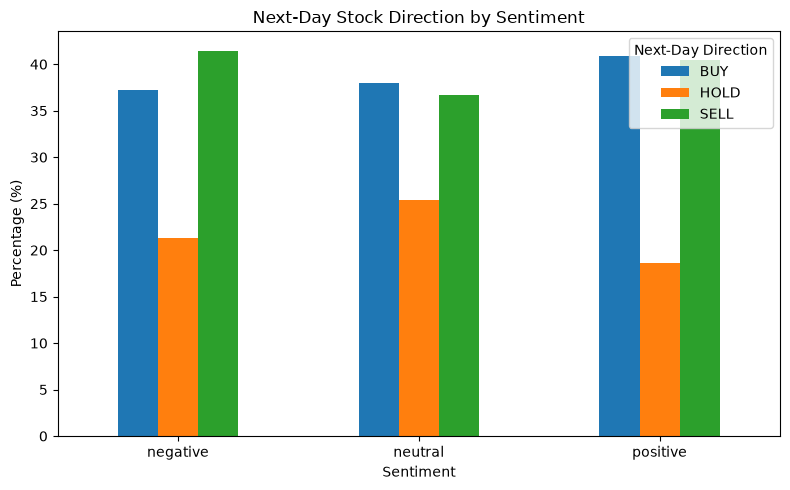

In [101]:
sentiment_target.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Next-Day Stock Direction by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Next-Day Direction")
plt.tight_layout()
plt.show()

In [102]:
#Evaluate the final model on the TEST set
y_pred_test = model_market.predict(X_test_market)

test_accuracy = accuracy_score(
    y_test,
    y_pred_test
)

print("Test Accuracy:", test_accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_test,
        target_names=["BUY", "HOLD", "SELL"]
    )
)

Test Accuracy: 0.4244747738076982

Classification Report:
              precision    recall  f1-score   support

         BUY       0.36      0.48      0.41      2209
        HOLD       0.60      0.20      0.30      1716
        SELL       0.46      0.52      0.49      2596

    accuracy                           0.42      6521
   macro avg       0.47      0.40      0.40      6521
weighted avg       0.46      0.42      0.41      6521



In [103]:
#Get all 3 sentiment probabilities
results = sentiment_pipeline(
    train["text"].iloc[:5].tolist(),
    truncation=True,
    max_length=512,
    top_k=3
)

results

[[{'label': 'neutral', 'score': 0.9177331924438477},
  {'label': 'negative', 'score': 0.056260570883750916},
  {'label': 'positive', 'score': 0.02600620500743389}],
 [{'label': 'neutral', 'score': 0.9177331924438477},
  {'label': 'negative', 'score': 0.056260570883750916},
  {'label': 'positive', 'score': 0.02600620500743389}],
 [{'label': 'neutral', 'score': 0.8282269239425659},
  {'label': 'positive', 'score': 0.11582233756780624},
  {'label': 'negative', 'score': 0.05595068261027336}],
 [{'label': 'neutral', 'score': 0.8282269239425659},
  {'label': 'positive', 'score': 0.11582233756780624},
  {'label': 'negative', 'score': 0.05595068261027336}],
 [{'label': 'neutral', 'score': 0.6221948862075806},
  {'label': 'positive', 'score': 0.36968693137168884},
  {'label': 'negative', 'score': 0.008118224330246449}]]

In [104]:
#training set
def get_sentiment_probabilities(texts, batch_size=16):
    positive_probs = []
    neutral_probs = []
    negative_probs = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]

        results = sentiment_pipeline(
            batch,
            truncation=True,
            max_length=512,
            top_k=3
        )

        for result in results:
            probs = {item["label"]: item["score"] for item in result}

            positive_probs.append(probs["positive"])
            neutral_probs.append(probs["neutral"])
            negative_probs.append(probs["negative"])

        print(f"Processed {min(i + batch_size, len(texts))} / {len(texts)}")

    return positive_probs, neutral_probs, negative_probs

In [105]:
positive_probs, neutral_probs, negative_probs = get_sentiment_probabilities(
    train["text"].tolist(),
    batch_size=16
)

Processed 16 / 30427
Processed 32 / 30427
Processed 48 / 30427
Processed 64 / 30427
Processed 80 / 30427
Processed 96 / 30427
Processed 112 / 30427
Processed 128 / 30427
Processed 144 / 30427
Processed 160 / 30427
Processed 176 / 30427
Processed 192 / 30427
Processed 208 / 30427
Processed 224 / 30427
Processed 240 / 30427
Processed 256 / 30427
Processed 272 / 30427
Processed 288 / 30427
Processed 304 / 30427
Processed 320 / 30427
Processed 336 / 30427
Processed 352 / 30427
Processed 368 / 30427
Processed 384 / 30427
Processed 400 / 30427
Processed 416 / 30427
Processed 432 / 30427
Processed 448 / 30427
Processed 464 / 30427
Processed 480 / 30427
Processed 496 / 30427
Processed 512 / 30427
Processed 528 / 30427
Processed 544 / 30427
Processed 560 / 30427
Processed 576 / 30427
Processed 592 / 30427
Processed 608 / 30427
Processed 624 / 30427
Processed 640 / 30427
Processed 656 / 30427
Processed 672 / 30427
Processed 688 / 30427
Processed 704 / 30427
Processed 720 / 30427
Processed 736 / 

In [106]:
train[
    [
        "text",
        "positive_prob",
        "neutral_prob",
        "negative_prob",
        "sentiment_strength"
    ]
].head()


KeyError: "['positive_prob', 'neutral_prob', 'negative_prob', 'sentiment_strength'] not in index"

In [107]:
print(train.columns.tolist())


['timestamp', 'ticker', 'tweet_url', 'label_1d_3class', 'author', 'category', 'session', 'market_regime', 'sector', 'market_cap_bucket', 'volatility_7d', 'relative_volume', 'rsi_14', 'distance_from_ma_20', 'return_5d', 'return_20d', 'above_ma_20', 'slope_ma_20', 'gap_open', 'intraday_range', 'text', 'sentiment', 'sentiment_score']


In [108]:
train["positive_prob"] = positive_probs
train["neutral_prob"] = neutral_probs
train["negative_prob"] = negative_probs

train["sentiment_strength"] = (
    train["positive_prob"] - train["negative_prob"]
)

In [109]:
train[
    [
        "text",
        "positive_prob",
        "neutral_prob",
        "negative_prob",
        "sentiment_strength"
    ]
].head()

,text,positive_prob,neutral_prob,negative_prob,sentiment_strength
0,"On New Year’s Day, Keith Gill, known as Roarin...",0.026006,0.917733,0.056261,-0.030254
1,"On New Year’s Day, Keith Gill, known as Roarin...",0.026006,0.917733,0.056261,-0.030254
2,CHINA ADDS 28 US FIRMS TO EXPORT CONTROL LIST ...,0.115822,0.828227,0.055951,0.059872
3,CHINA ADDS 28 US FIRMS TO EXPORT CONTROL LIST ...,0.115822,0.828227,0.055951,0.059872
4,"BofA on $NVDA (Buy; $190 PT): ""Reiterate Buy o...",0.369687,0.622195,0.008118,0.361569


In [111]:
validation_positive_probs, validation_neutral_probs, validation_negative_probs = get_sentiment_probabilities(
    validation["text"].tolist(),
    batch_size=16
)

Processed 16 / 6520
Processed 32 / 6520
Processed 48 / 6520
Processed 64 / 6520
Processed 80 / 6520
Processed 96 / 6520
Processed 112 / 6520
Processed 128 / 6520
Processed 144 / 6520
Processed 160 / 6520
Processed 176 / 6520
Processed 192 / 6520
Processed 208 / 6520
Processed 224 / 6520
Processed 240 / 6520
Processed 256 / 6520
Processed 272 / 6520
Processed 288 / 6520
Processed 304 / 6520
Processed 320 / 6520
Processed 336 / 6520
Processed 352 / 6520
Processed 368 / 6520
Processed 384 / 6520
Processed 400 / 6520
Processed 416 / 6520
Processed 432 / 6520
Processed 448 / 6520
Processed 464 / 6520
Processed 480 / 6520
Processed 496 / 6520
Processed 512 / 6520
Processed 528 / 6520
Processed 544 / 6520
Processed 560 / 6520
Processed 576 / 6520
Processed 592 / 6520
Processed 608 / 6520
Processed 624 / 6520
Processed 640 / 6520
Processed 656 / 6520
Processed 672 / 6520
Processed 688 / 6520
Processed 704 / 6520
Processed 720 / 6520
Processed 736 / 6520
Processed 752 / 6520
Processed 768 / 652

In [112]:
validation["positive_prob"] = validation_positive_probs
validation["neutral_prob"] = validation_neutral_probs
validation["negative_prob"] = validation_negative_probs

validation["sentiment_strength"] = (
    validation["positive_prob"] - validation["negative_prob"]
)

In [113]:
test_positive_probs, test_neutral_probs, test_negative_probs = get_sentiment_probabilities(
    test["text"].tolist(),
    batch_size=16
)

Processed 16 / 6521
Processed 32 / 6521
Processed 48 / 6521
Processed 64 / 6521
Processed 80 / 6521
Processed 96 / 6521
Processed 112 / 6521
Processed 128 / 6521
Processed 144 / 6521
Processed 160 / 6521
Processed 176 / 6521
Processed 192 / 6521
Processed 208 / 6521
Processed 224 / 6521
Processed 240 / 6521
Processed 256 / 6521
Processed 272 / 6521
Processed 288 / 6521
Processed 304 / 6521
Processed 320 / 6521
Processed 336 / 6521
Processed 352 / 6521
Processed 368 / 6521
Processed 384 / 6521
Processed 400 / 6521
Processed 416 / 6521
Processed 432 / 6521
Processed 448 / 6521
Processed 464 / 6521
Processed 480 / 6521
Processed 496 / 6521
Processed 512 / 6521
Processed 528 / 6521
Processed 544 / 6521
Processed 560 / 6521
Processed 576 / 6521
Processed 592 / 6521
Processed 608 / 6521
Processed 624 / 6521
Processed 640 / 6521
Processed 656 / 6521
Processed 672 / 6521
Processed 688 / 6521
Processed 704 / 6521
Processed 720 / 6521
Processed 736 / 6521
Processed 752 / 6521
Processed 768 / 652

In [114]:
#add probabilities and sentiment strength
test["positive_prob"] = test_positive_probs
test["neutral_prob"] = test_neutral_probs
test["negative_prob"] = test_negative_probs

test["sentiment_strength"] = (
    test["positive_prob"] - test["negative_prob"]
)

In [115]:
test[
    [
        "text",
        "positive_prob",
        "neutral_prob",
        "negative_prob",
        "sentiment_strength"
    ]
].head()


,text,positive_prob,neutral_prob,negative_prob,sentiment_strength
0,🚨 After-market buzz! $AIP $VCYT $OUST $LITE $Z...,0.219879,0.741747,0.038374,0.181506
1,🚨 After-market buzz! $AIP $VCYT $OUST $LITE $Z...,0.219879,0.741747,0.038374,0.181506
2,🚨 After-market buzz! $AIP $VCYT $OUST $LITE $Z...,0.219879,0.741747,0.038374,0.181506
3,🚨 After-market buzz! $AIP $VCYT $OUST $LITE $Z...,0.219879,0.741747,0.038374,0.181506
4,🚨 After-market buzz! $AIP $VCYT $OUST $LITE $Z...,0.219879,0.741747,0.038374,0.181506


In [116]:
print(validation.columns.tolist())


['timestamp', 'ticker', 'tweet_url', 'label_1d_3class', 'author', 'category', 'session', 'market_regime', 'sector', 'market_cap_bucket', 'volatility_7d', 'relative_volume', 'rsi_14', 'distance_from_ma_20', 'return_5d', 'return_20d', 'above_ma_20', 'slope_ma_20', 'gap_open', 'intraday_range', 'text', 'sentiment', 'sentiment_score', 'positive_prob', 'neutral_prob', 'negative_prob', 'sentiment_strength']


In [117]:
#Model4: Market + sentiment Strength
X_train_strength = pd.concat(
    [
        X_train_market,
        train[["sentiment_strength"]]
    ],
    axis=1
)

X_validation_strength = pd.concat(
    [
        X_validation_market,
        validation[["sentiment_strength"]]
    ],
    axis=1
)

X_test_strength = pd.concat(
    [
        X_test_market,
        test[["sentiment_strength"]]
    ],
    axis=1
)

In [118]:
print(X_train_strength.shape)
print(X_train_strength.columns.tolist())

(30427, 11)
['volatility_7d', 'relative_volume', 'rsi_14', 'distance_from_ma_20', 'return_5d', 'return_20d', 'above_ma_20', 'slope_ma_20', 'gap_open', 'intraday_range', 'sentiment_strength']


In [119]:
#Train model 4
from sklearn.linear_model import LogisticRegression

model_strength = LogisticRegression(max_iter=1000)

model_strength.fit(
    X_train_strength,
    y_train
)

C:\Users\chane\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [120]:
#predict on validation
y_pred_strength = model_strength.predict(
    X_validation_strength
)

print(y_pred_strength[:10])

[2 2 2 1 2 2 0 0 2 2]


In [121]:
#evaluate
from sklearn.metrics import accuracy_score, classification_report

accuracy_strength = accuracy_score(
    y_validation,
    y_pred_strength
)

print("Validation Accuracy:", accuracy_strength)

print("\nClassification Report:")
print(
    classification_report(
        y_validation,
        y_pred_strength,
        target_names=["BUY", "HOLD", "SELL"]
    )
)

Validation Accuracy: 0.41641104294478526

Classification Report:
              precision    recall  f1-score   support

         BUY       0.43      0.60      0.50      2651
        HOLD       0.43      0.28      0.34      1529
        SELL       0.39      0.29      0.33      2340

    accuracy                           0.42      6520
   macro avg       0.41      0.39      0.39      6520
weighted avg       0.41      0.42      0.40      6520



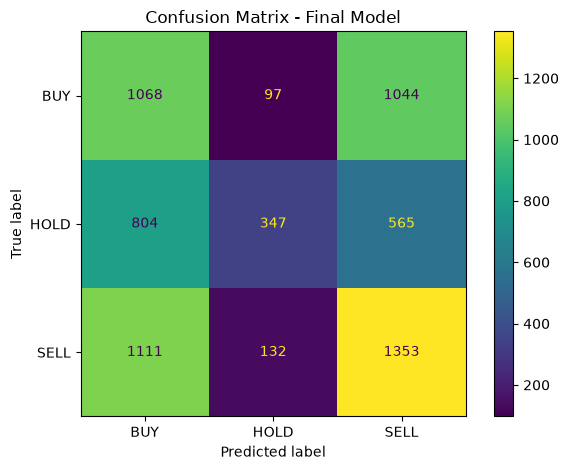

In [122]:
#confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred_test
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["BUY", "HOLD", "SELL"]
)

disp.plot()

plt.title("Confusion Matrix - Final Model")
plt.tight_layout()
plt.show()

In [123]:
#Create one final model comparison
final_results = pd.DataFrame({
    "Model": [
        "Baseline (Always BUY)",
        "Sentiment Only",
        "Market Only",
        "Market + Categorical Sentiment",
        "Market + Sentiment Strength"
    ],
    "Validation Accuracy": [
        0.4066,
        0.3965,
        0.4221,
        0.4170,
        0.4164
    ],
    "Macro F1": [
        None,
        0.23,
        0.39,
        0.39,
        0.39
    ]
})

final_results

,Model,Validation Accuracy,Macro F1
0,Baseline (Always BUY),0.4066,NaN
1,Sentiment Only,0.3965,0.23
2,Market Only,0.4221,0.39
3,Market + Categorical Sentiment,0.4170,0.39
4,Market + Sentiment Strength,0.4164,0.39


In [124]:
#Save the key statistoical results
statistical_results = pd.DataFrame({
    "Test": [
        "Chi-square test",
        "Cramér's V"
    ],
    "Result": [
        "p < 0.001",
        0.054
    ],
    "Interpretation": [
        "Sentiment and next-day direction are statistically associated",
        "The strength of the association is very weak"
    ]
})

statistical_results


,Test,Result,Interpretation
0,Chi-square test,p < 0.001,Sentiment and next-day direction are statistic...
1,Cramér's V,0.054,The strength of the association is very weak


In [125]:
baseline_accuracy = 0.4066
test_accuracy = 0.4244747738076982

improvement = test_accuracy - baseline_accuracy
relative_improvement = (improvement / baseline_accuracy) * 100

print("Absolute improvement:", improvement)
print("Relative improvement:", relative_improvement, "%")

Absolute improvement: 0.017874773807698197
Relative improvement: 4.396156863673929 %


In [126]:
test_baseline_accuracy = 2209 / 6521

improvement = test_accuracy - test_baseline_accuracy
relative_improvement = (improvement / test_baseline_accuracy) * 100

print("Test Baseline Accuracy:", test_baseline_accuracy)
print("Absolute improvement:", improvement)
print("Relative improvement:", relative_improvement, "%")

Test Baseline Accuracy: 0.33875172519552216
Absolute improvement: 0.08572304861217606
Relative improvement: 25.30556813037574 %


In [127]:
powerbi_columns = [
    'timestamp',
    'ticker',
    'label_1d_3class',
    'category',
    'market_regime',
    'sector',
    'market_cap_bucket',
    'volatility_7d',
    'relative_volume',
    'rsi_14',
    'distance_from_ma_20',
    'return_5d',
    'return_20d',
    'above_ma_20',
    'slope_ma_20',
    'gap_open',
    'intraday_range',
    'sentiment',
    'sentiment_score'
]

powerbi_data = train[powerbi_columns].copy()

powerbi_data.head()

,timestamp,ticker,label_1d_3class,category,market_regime,sector,market_cap_bucket,volatility_7d,relative_volume,rsi_14,distance_from_ma_20,return_5d,return_20d,above_ma_20,slope_ma_20,gap_open,intraday_range,sentiment,sentiment_score
0,2025-01-02 04:01:12-05:00,GME,2,Other,calm,Consumer,mid_cap,0.031125,0.568411,58.276897,0.059894,0.014239,0.149248,1.0,0.021540,0.001562,0.041862,neutral,0.917733
1,2025-01-02 04:01:12-05:00,U,0,Other,calm,Technology,large_cap,0.035080,0.561401,44.896435,-0.084930,0.004919,-0.073402,0.0,-0.008920,0.009773,0.030653,neutral,0.917733
2,2025-01-02 04:01:48-05:00,RTX,1,Other,calm,Industrials,mega_cap,0.006768,0.601497,42.555714,-0.010450,-0.007802,-0.024941,0.0,-0.007886,0.003038,0.010415,neutral,0.828227
3,2025-01-02 04:01:48-05:00,GD,2,Other,calm,Industrials,large_cap,0.007197,0.510319,34.192986,-0.013510,-0.006410,-0.046846,0.0,-0.014835,0.002354,0.012795,neutral,0.828227
4,2025-01-02 04:09:02-05:00,NVDA,0,Mergers & Acquisitions,calm,Technology,mega_cap,0.023086,0.859816,45.173355,-0.020842,-0.038519,-0.031306,0.0,0.001380,0.003491,0.030839,neutral,0.622195


In [128]:
print("Rows:", powerbi_data.shape[0])
print("Columns:", powerbi_data.shape[1])

Rows: 30427
Columns: 19


In [129]:
powerbi_data = powerbi_data.drop_duplicates()

In [131]:
powerbi_data['timestamp'] = pd.to_datetime(
    powerbi_data['timestamp'],
    utc=True
)

In [132]:
powerbi_data['timestamp'].head()

0   2025-01-02 09:01:12+00:00
1   2025-01-02 09:01:12+00:00
2   2025-01-02 09:01:48+00:00
3   2025-01-02 09:01:48+00:00
4   2025-01-02 09:09:02+00:00
Name: timestamp, dtype: datetime64[us, UTC]

In [133]:
powerbi_data.isnull().sum()

timestamp              0
ticker                 0
label_1d_3class        0
category               0
market_regime          0
sector                 0
market_cap_bucket      0
volatility_7d          0
relative_volume        0
rsi_14                 0
distance_from_ma_20    0
return_5d              0
return_20d             0
above_ma_20            0
slope_ma_20            0
gap_open               0
intraday_range         0
sentiment              0
sentiment_score        0
dtype: int64

In [134]:
print(powerbi_data['sentiment'].value_counts())
print(powerbi_data['label_1d_3class'].value_counts())
print(powerbi_data['ticker'].nunique())

sentiment
neutral     16724
positive     9678
negative     4025
Name: count, dtype: int64
label_1d_3class
0    11806
2    11718
1     6903
Name: count, dtype: int64
1723


In [135]:
powerbi_data.to_csv(
    'stock_sentiment_powerbi.csv',
    index=False
)

In [136]:
powerbi_columns = [
    'timestamp',
    'ticker',
    'label_1d_3class',
    'category',
    'market_regime',
    'sector',
    'market_cap_bucket',
    'volatility_7d',
    'relative_volume',
    'rsi_14',
    'distance_from_ma_20',
    'return_5d',
    'return_20d',
    'above_ma_20',
    'slope_ma_20',
    'gap_open',
    'intraday_range',
    'sentiment',
    'sentiment_score'
]

test = test[powerbi_columns].copy()

powerbi_data.head()

,timestamp,ticker,label_1d_3class,category,market_regime,sector,market_cap_bucket,volatility_7d,relative_volume,rsi_14,distance_from_ma_20,return_5d,return_20d,above_ma_20,slope_ma_20,gap_open,intraday_range,sentiment,sentiment_score
0,2025-01-02 09:01:12+00:00,GME,2,Other,calm,Consumer,mid_cap,0.031125,0.568411,58.276897,0.059894,0.014239,0.149248,1.0,0.021540,0.001562,0.041862,neutral,0.917733
1,2025-01-02 09:01:12+00:00,U,0,Other,calm,Technology,large_cap,0.035080,0.561401,44.896435,-0.084930,0.004919,-0.073402,0.0,-0.008920,0.009773,0.030653,neutral,0.917733
2,2025-01-02 09:01:48+00:00,RTX,1,Other,calm,Industrials,mega_cap,0.006768,0.601497,42.555714,-0.010450,-0.007802,-0.024941,0.0,-0.007886,0.003038,0.010415,neutral,0.828227
3,2025-01-02 09:01:48+00:00,GD,2,Other,calm,Industrials,large_cap,0.007197,0.510319,34.192986,-0.013510,-0.006410,-0.046846,0.0,-0.014835,0.002354,0.012795,neutral,0.828227
4,2025-01-02 09:09:02+00:00,NVDA,0,Mergers & Acquisitions,calm,Technology,mega_cap,0.023086,0.859816,45.173355,-0.020842,-0.038519,-0.031306,0.0,0.001380,0.003491,0.030839,neutral,0.622195


In [137]:
print(test['sentiment'].value_counts())
print(test['label_1d_3class'].value_counts())
print(test['ticker'].nunique())

sentiment
neutral     3958
positive    1840
negative     723
Name: count, dtype: int64
label_1d_3class
2    2596
0    2209
1    1716
Name: count, dtype: int64
1086


In [138]:
test.to_csv(
    'test.csv',
    index=False
)

In [139]:
powerbi_columns = [
    'timestamp',
    'ticker',
    'label_1d_3class',
    'category',
    'market_regime',
    'sector',
    'market_cap_bucket',
    'volatility_7d',
    'relative_volume',
    'rsi_14',
    'distance_from_ma_20',
    'return_5d',
    'return_20d',
    'above_ma_20',
    'slope_ma_20',
    'gap_open',
    'intraday_range',
    'sentiment',
    'sentiment_score'
]

validation_data = validation[powerbi_columns].copy()

powerbi_data.head()

,timestamp,ticker,label_1d_3class,category,market_regime,sector,market_cap_bucket,volatility_7d,relative_volume,rsi_14,distance_from_ma_20,return_5d,return_20d,above_ma_20,slope_ma_20,gap_open,intraday_range,sentiment,sentiment_score
0,2025-01-02 09:01:12+00:00,GME,2,Other,calm,Consumer,mid_cap,0.031125,0.568411,58.276897,0.059894,0.014239,0.149248,1.0,0.021540,0.001562,0.041862,neutral,0.917733
1,2025-01-02 09:01:12+00:00,U,0,Other,calm,Technology,large_cap,0.035080,0.561401,44.896435,-0.084930,0.004919,-0.073402,0.0,-0.008920,0.009773,0.030653,neutral,0.917733
2,2025-01-02 09:01:48+00:00,RTX,1,Other,calm,Industrials,mega_cap,0.006768,0.601497,42.555714,-0.010450,-0.007802,-0.024941,0.0,-0.007886,0.003038,0.010415,neutral,0.828227
3,2025-01-02 09:01:48+00:00,GD,2,Other,calm,Industrials,large_cap,0.007197,0.510319,34.192986,-0.013510,-0.006410,-0.046846,0.0,-0.014835,0.002354,0.012795,neutral,0.828227
4,2025-01-02 09:09:02+00:00,NVDA,0,Mergers & Acquisitions,calm,Technology,mega_cap,0.023086,0.859816,45.173355,-0.020842,-0.038519,-0.031306,0.0,0.001380,0.003491,0.030839,neutral,0.622195


In [140]:
validation_data.to_csv(
    'validation.csv',
    index=False
)